# imageseg: pre-trained canopy density model — minimal reproduction

**Paper:** Niedballa, J., Axtner, J. et al. *imageseg: an R package for deep learning-based image segmentation.* bioRxiv 2021.12.16.469125 (published: Methods in Ecology and Evolution, doi:10.1111/2041-210X.13984).
**Author code:** https://github.com/EcoDynIZW/imageseg (commit `bba7a54c174308cc3800ad59568c9c928db74694`; CRAN imageseg 0.5.2, MIT).

**Scope:** Run the exact author workflow from the package vignette — segment **canopy vs. sky** in the 3 example canopy photographs shipped with the *imageseg* package, using the pre-trained canopy model from Zenodo record [6861157](https://doi.org/10.5281/zenodo.6861157), and derive the **canopy density** metric. Compare with the author's published reference values (**0.957, 0.401, 0.756**, vignette §"Model predictions on images (v2)").

**Not in scope:** understory model, (re)training, batch processing, multi-class or grayscale models. A 3-image run does not verify the paper's dataset-level accuracy (Dice 0.91 canopy).

**Runtime:** select **CPU** — the paper reports ~100 canopy images/minute on a laptop CPU; no GPU is required. Expected wall time ~15 min; downloads ~400 MB (R packages, TF 2.15 CPU wheel, 101 MB model zip). Use *Runtime → Run all*.

**Language note:** the scientific code is the authors' own R package; Python is only the launcher that writes pinned R scripts to `/content` and runs them with `Rscript` (the Colab CLI cannot execute a native R-kernel notebook).

**JA:** 本ノートブックは imageseg（bioRxiv 10.1101/2021.12.16.469125）の著者 R コードをそのまま Colab 上で実行し、パッケージ同梱のキャノピー例画像3枚に学習済みモデル（Zenodo 6861157）を適用して林冠密度を算出します。リファレンス値（0.957 / 0.401 / 0.756）と比較します。ランタイムは CPU を選択してください（GPU 不要）。Python は R 起動用のランチャーに過ぎません。

## 1. Runtime and R inventory

Check that `Rscript` is present on this Colab VM (Colab CPU/GPU images ship R) and record the R version and library path used below.

**JA:** このVMの R の存在とバージョンを確認。

In [ ]:
import subprocess, sys, shutil
print("python:", sys.version.split()[0])
rscript = shutil.which("Rscript")
print("Rscript:", rscript)
assert rscript, "Rscript not found on this runtime"
print(subprocess.run([rscript, "-e", "cat(R.version.string)"], capture_output=True, text=True).stdout.strip())
print(subprocess.run([rscript, "-e", "cat(.libPaths(), sep='\n')"], capture_output=True, text=True).stdout.strip())


python: 3.13.15
Rscript: /usr/bin/Rscript


R version 4.6.1 (2026-06-24)


/usr/local/lib/R/site-library
/usr/lib/R/site-library
/usr/lib/R/library


## 2. System libraries

`magick` (the R image backend used by the authors' preprocessing) needs ImageMagick headers; `curl`/`openssl` headers are dependencies of other R packages.

**JA:** R パッケージのビルドに必要なシステムライブラリを導入。

In [ ]:
import subprocess, sys
subprocess.run(["apt-get", "update", "-qq"], check=True)
subprocess.run(["apt-get", "install", "-y", "-qq", "libmagick++-dev", "libcurl4-openssl-dev", "libssl-dev"],
               check=True)
print("apt ok")


apt ok


## 3. R packages (pinned versions)

Install the author's dependencies from CRAN, then pin **R `tensorflow` 2.15.0** and **R `keras` 2.15.0** from the CRAN archive. This is deliberate: the current CRAN `keras` 3.x no longer exports `load_model_hdf5`, which `imageseg::loadModel()` calls (`R/loadModel.R:24`).

**JA:** 著者の依存パッケージをCRANから、keras/tensorflow R は 2.15.0 に固定してインストール（keras 3.x には load_model_hdf5 が無いため）。

In [ ]:
SETUP_PKGS_R = r'''
options(Ncpus = 4, timeout = 1800)
install.packages(c("magick", "purrr", "tibble", "dplyr", "magrittr", "foreach", "doParallel", "imageseg"))
install.packages("https://cran.r-project.org/src/contrib/Archive/tensorflow/tensorflow_2.15.0.tar.gz",
                 repos = NULL, type = "source")
install.packages("https://cran.r-project.org/src/contrib/Archive/keras/keras_2.15.0.tar.gz",
                 repos = NULL, type = "source")
ip <- installed.packages()[, "Version"]
for (p in c("imageseg", "magick", "keras", "tensorflow", "reticulate")) cat(p, ip[p], "\n")
cat("R_PKGS_DONE\n")
'''
open("/content/setup_pkgs.R", "w").write(SETUP_PKGS_R)
r = subprocess.run(["Rscript", "/content/setup_pkgs.R"], capture_output=True, text=True)
print(r.stdout, end="")
print(r.stderr, end="", file=sys.stderr)
r.check_returncode()


begin installing package ‘RcppTOML’
begin installing package ‘png’
begin installing package ‘here’
begin installing package ‘config’
* installing *source* package ‘here’ ...
** this is package ‘here’ version ‘1.0.2’
** package ‘here’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
*** copying figures
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (here)
begin installing package ‘zeallot’
* installing *source* package ‘config’ ...
** this is package ‘config’ version ‘0.3.2’
** package ‘config’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** inst
** byte-compile and prepare package for lazy loading
** help
*** 

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘RcppTOML’, ‘here’, ‘png’, ‘config’, ‘tfautograph’, ‘reticulate’, ‘tensorflow’, ‘tfruns’, ‘zeallot’, ‘iterators’, ‘keras’

trying URL 'https://cran.rstudio.com/src/contrib/RcppTOML_0.2.3.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/here_1.0.2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/png_0.1-9.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/config_0.3.2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/tfautograph_0.3.2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/reticulate_1.47.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/tensorflow_2.20.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/tfruns_1.5.4.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/zeallot_0.2.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/iterators_1.0.14.tar.gz'
trying URL 'https://cran.rstudio.com/src/con

## 4. TensorFlow 2.15.1 in a Python 3.11 conda env

TensorFlow 2.15 wheels require Python ≤ 3.11 while the Colab system Python is newer, so a dedicated miniconda environment is created (via the authors' own `reticulate`/`keras` installation route) and `reticulate` is pointed at it.

**JA:** TF 2.15 は Python 3.11 専用のため、miniconda 環境を作成して tensorflow-cpu 2.15.1 を導入。

In [ ]:
SETUP_TF_R = r'''
options(timeout = 3600)
if (!dir.exists(path.expand("~/.local/share/r-miniconda"))) reticulate::install_miniconda()
envs <- reticulate::conda_list()$name
if ("r-imageseg" %in% envs) {
  env_py <- system2(file.path(reticulate::conda_list()[reticulate::conda_list()$name == "r-imageseg", "python"]), "-V", stdout = TRUE)
  if (!length(grep("3[.]11", env_py))) {
    reticulate::conda_remove("r-imageseg")
    reticulate::conda_create("r-imageseg", python_version = "3.11")
  }
} else {
  reticulate::conda_create("r-imageseg", python_version = "3.11")
}
reticulate::py_install("tensorflow-cpu==2.15.1", envname = "r-imageseg", pip = TRUE)
cat("TF_ENV_DONE\n")
'''
open("/content/setup_tf.R", "w").write(SETUP_TF_R)
r = subprocess.run(["Rscript", "/content/setup_tf.R"], capture_output=True, text=True)
print(r.stdout, end="")
print(r.stderr, end="", file=sys.stderr)
r.check_returncode()


PREFIX=/root/.local/share/r-miniconda
Unpacking bootstrapper...
Unpacking payload...
Extracting ca-certificates-2026.7.22-hbd8a1cb_0.conda
Extracting libgomp-16.2.0-he0feb66_4.conda
Extracting libzlib-1.3.2-h25fd6f3_3.conda
Extracting nlohmann_json-abi-3.12.0-h0f90c79_2.conda
Extracting pybind11-abi-11-hc364b38_1.conda
Extracting python_abi-3.14-9_cp314.conda
Extracting tzdata-2026c-h151e31d_0.conda
Extracting _openmp_mutex-4.5-20_gnu.conda
Extracting zstd-1.5.7-hb78ec9c_7.conda
Extracting ld_impl_linux-64-2.46.1-default_hbd61a6d_102.conda
Extracting libgcc-16.2.0-ha9f2e26_4.conda
Extracting bzip2-1.0.8-hda65f42_10.conda
Extracting c-ares-1.34.8-hebe6cf0_2.conda
Extracting keyutils-1.6.3-h7cc23a3_1.conda
Extracting libev-4.33-h280c20c_3.conda
Extracting libexpat-2.8.1-hecca717_1.conda
Extracting libffi-3.7.0-h81df57d_1.conda
Extracting libiconv-1.18-h0cb94f2_3.conda
Extracting liblzma-5.8.3-hb03c661_1.conda
Extracting libmpdec-4.0.0-hb03c661_2.conda
Extracting libstdcxx-16.2.0-h934c35e

* Installing Miniconda -- please wait a moment ...
* Downloading 'https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh' ...
trying URL 'https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh'
Content type 'application/octet-stream' length 124514161 bytes (118.7 MB)
downloaded 118.7 MB

+ /usr/bin/bash /tmp/RtmpIKENvt/Miniforge3-Linux-x86_64.sh -b -u -p '/root/.local/share/r-miniconda'
warning  libmamba Security Warning: This transaction includes executing package scripts (pre/post-link/unlink) if present. These scripts can contain arbitrary code. Please ensure you trust the package sources.
+ /root/.local/share/r-miniconda/bin/conda update --yes --name base conda
+ /root/.local/share/r-miniconda/bin/conda create --yes --name r-reticulate 'python=3.12' numpy --quiet -c conda-forge
WARNING conda.conda_pypi.main:notify_conda_pypi_tip(158): 
  Did you know? You can install many PyPI packages with conda
  using co

## 5. Verify the Keras/TF stack

Confirm that R `keras` 2.15 loads against the Python 3.11 environment and reports TF 2.15.1.

**JA:** keras 2.15 + TF 2.15.1 の組み合わせが読み込めるか確認。

In [ ]:
CHECK_R = r'''
Sys.setenv(RETICULATE_PYTHON = "/root/.local/share/r-miniconda/envs/r-imageseg/bin/python")
suppressMessages(library(tensorflow))
suppressMessages(library(keras))
cat("R keras:", as.character(packageVersion("keras")), "\n")
cat("TF:", tf$`__version__`, "\n")
cat("KERAS_CHECK_DONE\n")
'''
open("/content/check_keras.R", "w").write(CHECK_R)
r = subprocess.run(["Rscript", "/content/check_keras.R"], capture_output=True, text=True)
print(r.stdout, end="")
print(r.stderr, end="", file=sys.stderr)
r.check_returncode()


R keras: 2.15.0 
TF: 2.15.1 
KERAS_CHECK_DONE


2026-10-05 05:17:59.658392: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 6. Pre-trained canopy model (Zenodo record 6861157)

Download `imageseg_canopy_model.zip` (101,009,262 bytes; md5 `3b466d066a1407d04b0627818ad5372f` per the record's file metadata) and extract it. The zip contains the `.hdf5` model plus the authors' example classifications. The 101 MB archive is downloaded in full because the record offers no per-file extraction.

**JA:** 学習済み canopy モデル（Zenodo 6861157、101 MB）をダウンロードし md5 検証の上展開。

In [ ]:
import subprocess, hashlib, sys
URL = "https://zenodo.org/record/6861157/files/imageseg_canopy_model.zip?download=1"
subprocess.run(["curl", "-sSL", "--fail", "--retry", "3", "-o", "/content/imageseg_canopy_model.zip", URL], check=True)
h = hashlib.md5(open("/content/imageseg_canopy_model.zip", "rb").read()).hexdigest()
print("md5:", h, "match:", h == "3b466d066a1407d04b0627818ad5372f")
assert h == "3b466d066a1407d04b0627818ad5372f"
subprocess.run(["unzip", "-o", "-q", "/content/imageseg_canopy_model.zip", "-d", "/content/model_can"], check=True)
subprocess.run(["find", "/content/model_can", "-maxdepth", "2", "-type", "f", "-printf", "%s %p\n"])


md5: 3b466d066a1407d04b0627818ad5372f match: True


CompletedProcess(args=['find', '/content/model_can', '-maxdepth', '2', '-type', 'f', '-printf', '%s %p\n'], returncode=0)

## 7. Resize the example images (author preprocessing)

The 3 canopy example photographs ship inside the installed *imageseg* package (`inst/images/canopy/raw`). `resizeImages(type="canopy")` crops/resizes them to the model's 256×256 input with the authors' own function (`R/resizeImages.R:96-97`).

**JA:** パッケージ同梱の例画像3枚を著者関数で 256×256 にリサイズ。

In [ ]:
RESIZE_R = r'''
suppressMessages(library(imageseg))
wd_raw <- system.file("images/canopy/raw", package = "imageseg")
imgs <- list.files(wd_raw, full.names = TRUE)
cat("raw images:", length(imgs), "\n"); cat(basename(imgs), sep = "\n")
resizeImages(imageDir = wd_raw, type = "canopy", outDir = "/content/canopy_resized")
cat("RESIZE_DONE\n")
'''
open("/content/resize.R", "w").write(RESIZE_R)
r = subprocess.run(["Rscript", "/content/resize.R"], capture_output=True, text=True)
print(r.stdout, end="")
print(r.stderr, end="", file=sys.stderr)
r.check_returncode()


raw images: 3 
canopy_example_hemi_raw1.JPG
canopy_example_raw1.JPG
canopy_example_raw2.JPG

  |                                                                            
  |                                                                      |   0%
  |                                                                            
  |=======================                                               |  33%
  |                                                                            
  |===============================================                       |  67%
  |                                                                            
  |======================================================================| 100%
RESIZE_DONE


Processing 3 images in /usr/local/lib/R/site-library/imageseg/images/canopy/raw  on 1 cores.


## 8. Input preview

Display the 3 resized input images (the actual model inputs) before running any prediction.

**JA:** モデル入力となるリサイズ後の3枚を表示。

PREVIEW_DONE


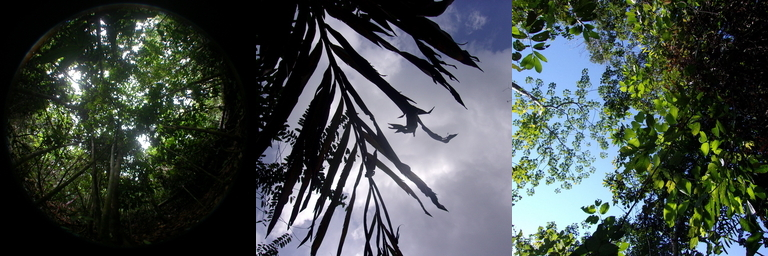

In [ ]:
PREVIEW_R = r'''
suppressMessages(library(magick))
imgs <- image_read(list.files("/content/canopy_resized", full.names = TRUE))
panel <- image_append(imgs, stack = FALSE)
image_write(panel, "/content/out/input_panel.png")
cat("PREVIEW_DONE\n")
'''
import os, subprocess
os.makedirs("/content/out", exist_ok=True)
open("/content/preview.R", "w").write(PREVIEW_R)
r = subprocess.run(["Rscript", "/content/preview.R"], capture_output=True, text=True)
print(r.stdout, end="")
print(r.stderr, end="", file=sys.stderr)
r.check_returncode()
from IPython.display import Image, display
display(Image(filename="/content/out/input_panel.png"))


## 9. Load model and run the author's inference

`loadImages` → `imagesToKerasInput` (sRGB, values 0–1, per `R/imagesToKerasInput.R:126-134`) → `loadModel` (`R/loadModel.R`, restoring the authors' custom loss/metrics) → `imageSegmentation` (predict + threshold 0.5 + density summary, `R/imageSegmentation.R`). If the legacy hdf5 (saved with Keras 2.2) fails to load with its optimizer state, we retry with `compile = FALSE` — inference-only, a documented adaptation.

**JA:** 著者関数でモデル読込・推論・林冠密度集計を実行。コンパイル済み読込が失敗した場合は compile=FALSE で再試行（推論のみに影響しない適応）。

In [ ]:
RUN_R = r'''
Sys.setenv(RETICULATE_PYTHON = "/root/.local/share/r-miniconda/envs/r-imageseg/bin/python")
suppressMessages(library(imageseg))
suppressMessages(library(keras))
cat("imageseg:", as.character(packageVersion("imageseg")), "\n")

images <- loadImages(imageDir = "/content/canopy_resized")
x <- imagesToKerasInput(images)

model_file <- list.files("/content/model_can", pattern = "canopy_model.*hdf5$", full.names = TRUE, recursive = TRUE)
cat("model file:", model_file, "\n")
custom <- imageseg:::restoreCustomObjects()
model <- tryCatch({
  keras::load_model_hdf5(filepath = model_file, custom_objects = custom)
}, error = function(e) {
  cat("loadModel with compile failed, retrying with compile = FALSE:", conditionMessage(e), "\n")
  keras::load_model_hdf5(filepath = model_file, custom_objects = custom, compile = FALSE)
})
cat("model loaded\n")

results <- imageSegmentation(model = model, x = x)
print(results$summary)
cat("not_predicted:", results$summary$not_predicted, "\n")
cat("REFERENCE (vignette): 0.957 0.401 0.756\n")
dir.create("/content/out", showWarnings = FALSE)
panel <- magick::image_append(c(
  magick::image_append(results$image, stack = TRUE),
  magick::image_append(results$prediction, stack = TRUE),
  magick::image_append(results$prediction_binary, stack = TRUE)))
magick::image_write(panel, path = "/content/out/examples.png")
cat("WORKFLOW_DONE\n")
'''
open("/content/run_imageseg.R", "w").write(RUN_R)
r = subprocess.run(["Rscript", "/content/run_imageseg.R"], capture_output=True, text=True)
print(r.stdout, end="")
print(r.stderr, end="", file=sys.stderr)
r.check_returncode()


imageseg: 0.5.2 
model file: /content/model_can/imageseg_canopy_model.hdf5 
model loaded

1/1 [==============================] - 3s 3s/step
                                              filename format width height
1 /content/canopy_resized/canopy_example_hemi_raw1.tif   JPEG   256    256
2      /content/canopy_resized/canopy_example_raw1.tif   JPEG   256    256
3      /content/canopy_resized/canopy_example_raw2.tif   JPEG   256    256
  colorspace matte filesize density not_predicted predicted
1       sRGB FALSE    78517 300x300         0.966     0.034
2       sRGB FALSE    81582   72x72         0.405     0.595
3       sRGB FALSE   112843   72x72         0.766     0.234
not_predicted: 0.966 0.405 0.766 
REFERENCE (vignette): 0.957 0.401 0.756
WORKFLOW_DONE


found 3 images
colorspace is sRGB
3 images, 256 x 256 pixels, 3 color channels
2026-10-05 05:19:11.469505: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 10. Result: input | prediction | binary mask

The `$examples` panel produced by `imageSegmentation` — for each image: original input, predicted sky probability (grey = uncertainty around 0.5), binary mask. Sky fraction = *openness*; the complement is **canopy density**.

**JA:** imageSegmentation が出力する入力｜予測確率｜二値マスクのパネル。

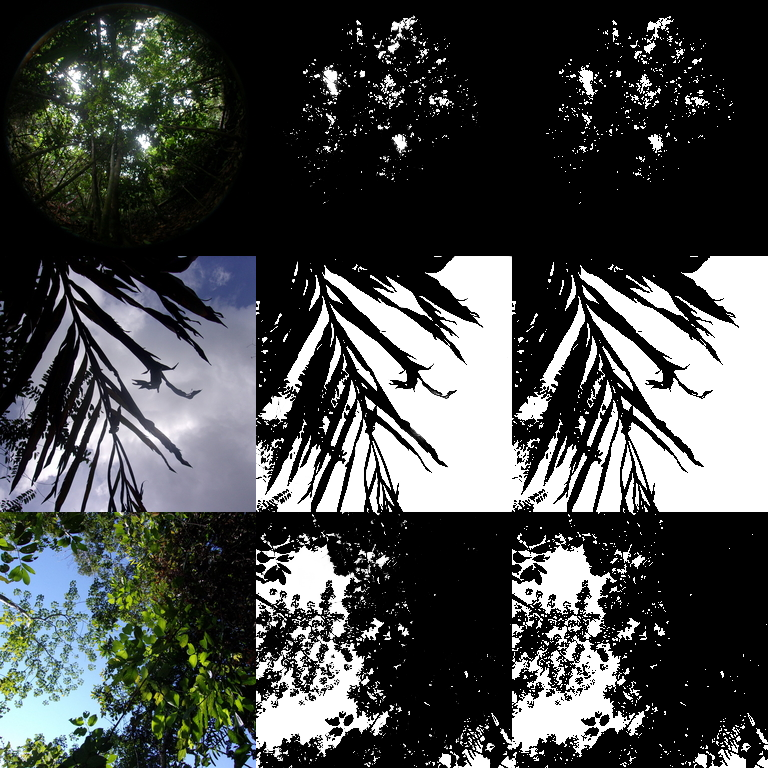

In [ ]:
from IPython.display import Image, display
display(Image(filename="/content/out/examples.png"))


## 11. Canopy density vs. author reference values

`not_predicted` from `results$summary` is canopy density (fraction of pixels not predicted as sky, rounded to 3 decimals by the authors' code). The vignette's manual computation for these same 3 images reports **0.957, 0.401, 0.756** (order corresponds to the alphabetical raw-file listing: `canopy_example_hemi_raw1.JPG`, `canopy_example_raw1.JPG`, `canopy_example_raw2.JPG`).

**JA:** 林冠密度をビネットのリファレンス値（0.957 / 0.401 / 0.756）と比較する。

In [ ]:
COMPARE_R = r'''
suppressMessages(library(imageseg))
Sys.setenv(RETICULATE_PYTHON = "/root/.local/share/r-miniconda/envs/r-imageseg/bin/python")
suppressMessages(library(keras))
images <- loadImages(imageDir = "/content/canopy_resized")
x <- imagesToKerasInput(images)
model_file <- list.files("/content/model_can", pattern = "canopy_model.*hdf5$", full.names = TRUE, recursive = TRUE)
model <- keras::load_model_hdf5(filepath = model_file, custom_objects = imageseg:::restoreCustomObjects(), compile = FALSE)
pred <- predict(model, x)
dens <- round(apply(round(pred), 1, function(m) 1 - mean(m)), 3)
ref <- c(0.957, 0.401, 0.756)
df <- data.frame(image = list.files("/content/canopy_resized"),
                 canopy_density = as.numeric(dens),
                 vignette_reference = ref,
                 abs_diff = abs(as.numeric(dens) - ref))
print(df, row.names = FALSE)
cat("max_abs_diff:", max(df$abs_diff), "\n")
cat("COMPARE_DONE\n")
'''
open("/content/compare.R", "w").write(COMPARE_R)
r = subprocess.run(["Rscript", "/content/compare.R"], capture_output=True, text=True)
print(r.stdout, end="")
print(r.stderr, end="", file=sys.stderr)
r.check_returncode()



1/1 [==============================] - 3s 3s/step
                        image canopy_density vignette_reference abs_diff
 canopy_example_hemi_raw1.tif          0.966              0.957    0.009
      canopy_example_raw1.tif          0.405              0.401    0.004
      canopy_example_raw2.tif          0.766              0.756    0.010
max_abs_diff: 0.01 
COMPARE_DONE


found 3 images
colorspace is sRGB
3 images, 256 x 256 pixels, 3 color channels
2026-10-05 05:19:25.367008: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 12. Interpretation and limitations

**What this verifies:** the authors' own R workflow (`resizeImages` → `loadImages` → `imagesToKerasInput` → `loadModel` → `imageSegmentation`) runs end-to-end on Colab CPU, and the pre-trained canopy model reproduces the vignette's canopy densities on the package's 3 example images (see §11; small deviations of a few 0.001 are expected from the TF 2.15 vs. TF 2.2 backend difference).

**What this does not verify:** the paper's dataset-level accuracy (canopy Dice 0.91 / Jaccard 0.87), understory model, or retraining pipelines. A 3-image demo is a faithfulness check, not a benchmark.

**Version note:** the paper trained with Keras 2.4.3 / TF 2.2.0 on GPU; this notebook infers with Keras 2.15 / TF 2.15.1 on CPU (the paper itself reports CPU inference at ~100 images/min). The CRAN `imageseg` 0.5.2 code is identical to the pinned GitHub commit for the functions used.

**JA:** 本デモは著者コードのエンドツーデンド実行とビネット値の再現確認であり、論文のデータセット精度検証ではない。TF 2.15 での推論は TF 2.2 時代と数桁 0.001 未満の差が出る可能性がある。

## References
- Paper: bioRxiv 2021.12.16.469125 / MEE doi:10.1111/2041-210X.13984
- Code: github.com/EcoDynIZW/imageseg @ `bba7a54`, CRAN imageseg 0.5.2 (MIT)
- Vignette (workflow + reference values): `vignettes/imageseg.pdf` in the repo
- Weights: Zenodo record 6861157, file `imageseg_canopy_model.zip`
- Example images: `imageseg` package `inst/images/canopy/raw` (also in the Dryad collection doi:10.5061/dryad.x0k6djhnj, license CC0-1.0 per Dryad API metadata)
